### Optimal control of the Wilson-Cowan model
This notebook shows how to compute the optimal control (OC) signal for the Wilson-Cowan model for a simple example task.

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import os

from evotorch import Problem, Solution
from evotorch.algorithms import SNES
from evotorch.logging import StdOutLogger
import torch
import math

from scipy.fft import fft, ifft, fftfreq

while os.getcwd().split(os.sep)[-1] != "neurolib":
    os.chdir('..')

# We import the model, stimuli, and the optimal control package
from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput

# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
def get_spectrum(timeseries):
    spectrum = fft(timeseries)
    spectrum[0] = 0.
    T = len(timeseries)
    return 2.0/T * np.abs(spectrum[0:T//2])


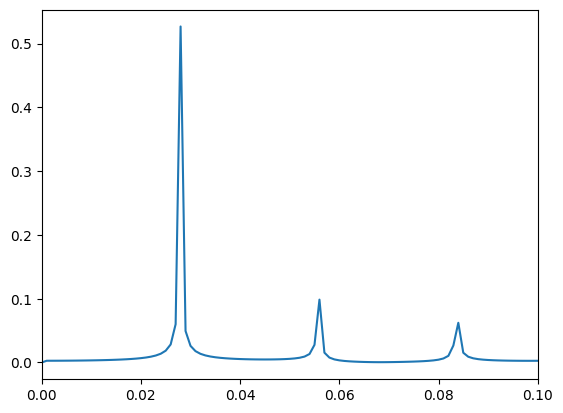

In [66]:
# We import the model
wc = WCModel()

# Some parameters to define stimulation signals
dt = wc.params["dt"]
duration = 1000.
time = np.arange(0, duration+dt, dt)
T = len(time)

# We set the duration of the simulation and the initial values
wc.params["duration"] = duration
wc.params["exc_ext_baseline"] = 1.
wc.run()
wc.params["exc_ext_baseline"] = 0.

state_timeseries = wc.exc[0,:]

target_spectrum = get_spectrum(state_timeseries)
xf = fftfreq(T, dt)[:T//2]

plt.plot(xf, target_spectrum)

plt.xlim(0,0.1)
plt.show()

In [110]:
class OffsetRastrigin(Problem):
    def __init__(self, params: str = ["exc_ext_baseline"], target_spectrum: float = np.zeros((len(target_spectrum)))):
        super().__init__(
            objective_sense="min",
            solution_length=len(params),
            initial_bounds=(-1, 1),
        )

        # Store the A parameter for evaluation
        self._params = params
        self.target = target_spectrum
        # Generate a random offset with center 0 and standard deviation 1
        #self._x_prime = self.make_gaussian(d, center=0.0, stdev=0.2)

    def _evaluate(self, solution: Solution):
        
        for k in range(len(solution)):
            x = solution.values[k]
            x_numpy = torch.Tensor.numpy(x)
            wc.params[self._params[k]] = x_numpy

        wc.run()
        spectrum = get_spectrum(wc.exc[0,:])
        f = torch.sum(torch.abs(torch.Tensor(spectrum) - target_spectrum))
        #f = abs(self._dim * self.solution_length - torch.sum(x.pow(2.0)))
        solution.set_evals(f)

# Define a Problem instance wrapping the function
# Solutions have length 10
problem = OffsetRastrigin(params=["exc_ext_baseline"], target_spectrum=target_spectrum)

searcher  = SNES(
        problem,
        radius_init=4.,
        center_init=1.,
        center_learning_rate = 0.1,
        popsize=10,
        )
searcher.run(1)

ReadOnlyTensor(0.7049) ReadOnlyTensor(-1.5086)


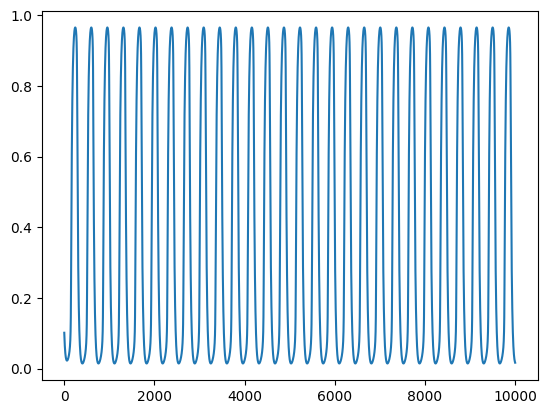

ReadOnlyTensor(0.9096) ReadOnlyTensor(-0.1578)


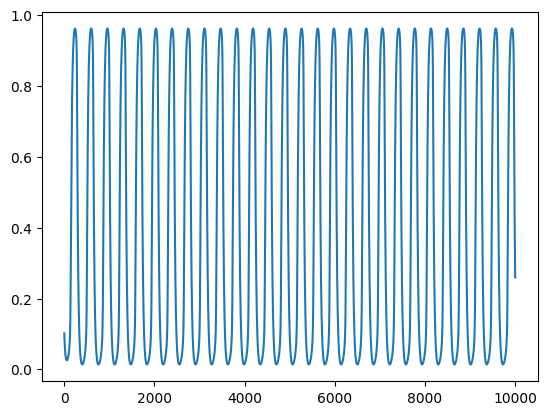

ReadOnlyTensor(0.8925) ReadOnlyTensor(-0.2809)


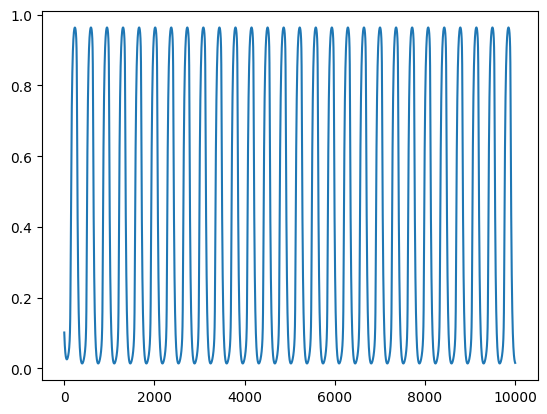

ReadOnlyTensor(1.1009) ReadOnlyTensor(-0.0231)


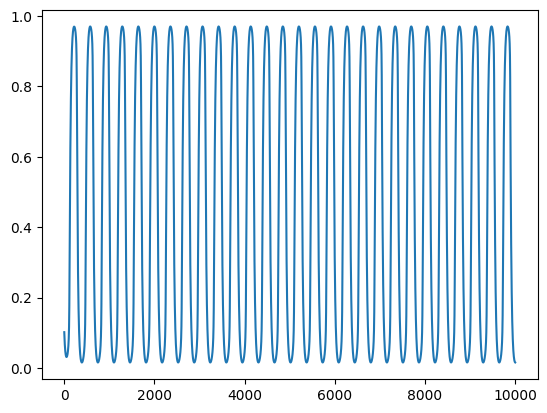

ReadOnlyTensor(1.3329) ReadOnlyTensor(-1.9649)


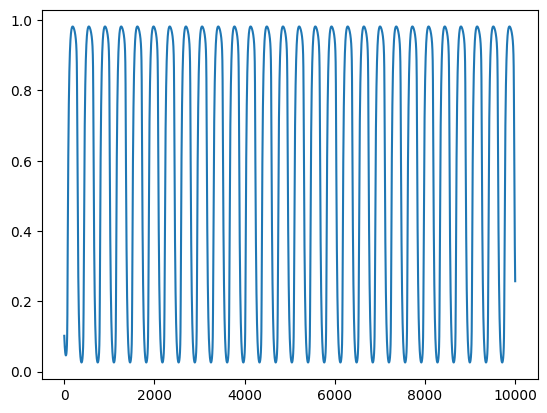

ReadOnlyTensor(0.9385) ReadOnlyTensor(-0.1900)


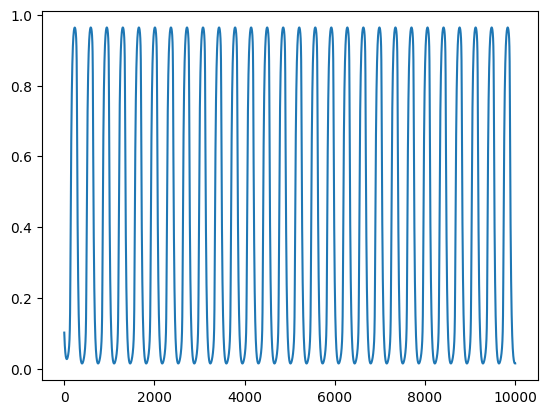

ReadOnlyTensor(1.3155) ReadOnlyTensor(-1.4302)


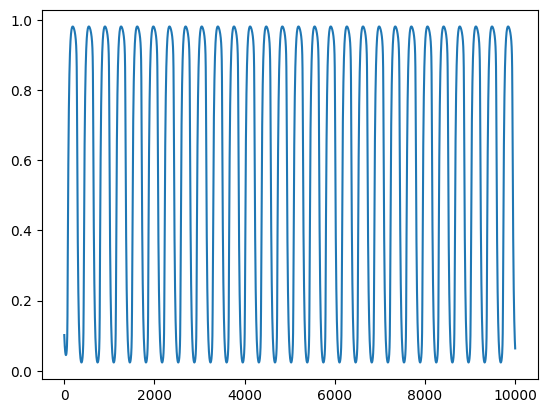

ReadOnlyTensor(0.6911) ReadOnlyTensor(-1.9001)


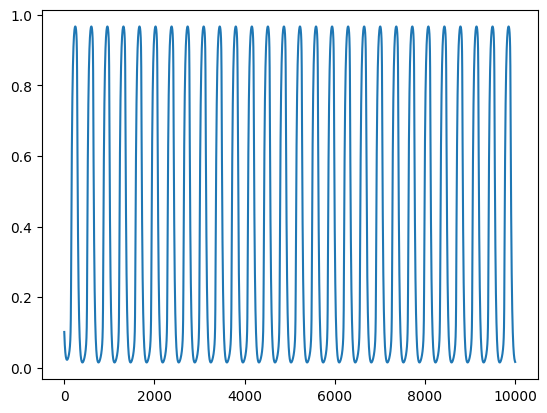

ReadOnlyTensor(0.9548) ReadOnlyTensor(-0.0845)


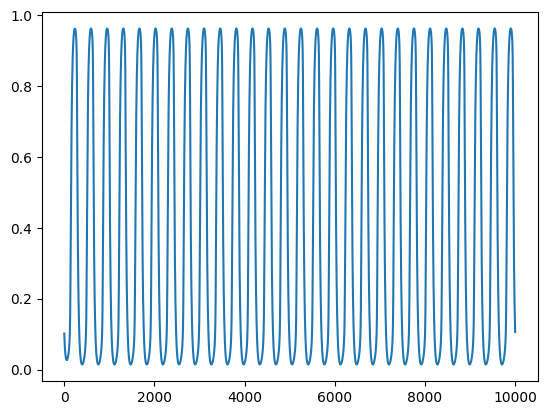

ReadOnlyTensor(1.0218) ReadOnlyTensor(0.0270)


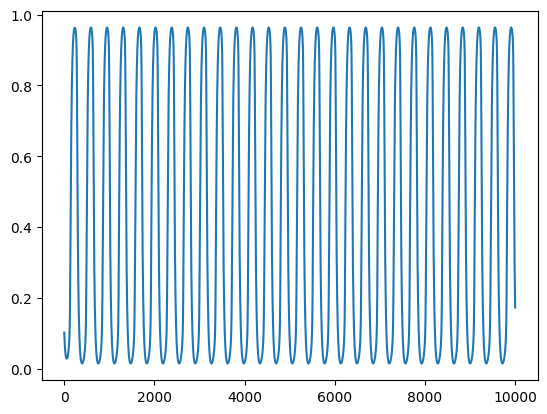

In [115]:
for k in range(10):
    problem = OffsetRastrigin(params=["exc_ext_baseline", "inh_ext_baseline"], target_spectrum=target_spectrum)
    #searcher = SNES(problem, stdev_init=1)
    searcher  = SNES(
        problem,
        radius_init=2.,
        center_init=0.5,
        center_learning_rate = 0.1,
        popsize=40,
        )
    
    searcher.run(400)
    exc_ext_baseline, inh_ext_baseline = searcher.status["best"][0], searcher.status["best"][1]
    
    print(exc_ext_baseline, inh_ext_baseline)
    wc.params["exc_ext_baseline"] = torch.Tensor.numpy(exc_ext_baseline)
    wc.params["inh_ext_baseline"] = torch.Tensor.numpy(inh_ext_baseline)
    wc.run()

    plt.plot(wc.exc[0,:])
    plt.show()

In [6]:
center_solution = searcher.status["pop_best"]  # Get the best solution in the population
policy_net = problem.to_policy(center_solution)  # Instantiate the policy from the best solution
for _ in range(10): # Visualize 10 episodes
    result = problem.visualize(policy_net)
    print('Visualised episode has cumulative reward:', result['cumulative_reward'])

AttributeError: 'Problem' object has no attribute 'to_policy'